# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Clara Nadia Adigunawan
- **Email:** clara2nadia1@gmail.com
- **ID Dicoding:** claranadia

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada kombinasi hari dan jam apa rata-rata jumlah penyewaan tertinggi tercatat selama 2011–2012?
- **Pertanyaan 2:** Bagaimana kondisi cuaca (weatehrsit) memengaruhi total penyewaan sepanjang 2011–2012?
- **Pertanyaan 3:** Bagaimana proporsi dan tren pengguna casual vs registered per bulan sepanjang 2011–2012, dan apakah proporsinya bergeser antar musim (season)?
- **Pertanyaan 4:** Bagaimana kondisi lingkungan, seperti temperatur (temp/atemp), hum, dan windspeed memengaruhi penyewaan selama 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.ticker as ticker
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load hours_df

In [ ]:
hours_df = pd.read_csv("hour.csv")
hours_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


#### Load days_df

In [ ]:
days_df = pd.read_csv("day.csv")
days_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


**Insight:** (Opsional)

- days_df memiliki 731 baris data (hari) yang tercatat, sedangkan hours_df memiliki 17.379 baris data (jam) sehingga ada ketidakcocokan jumlah data jam dengan hari yang tercatat. Artinya, ada beberapa jam yang tidak tercatat untuk hari tertentu.
- days_df memiliki daftar kolom yang sama dengan hours_df, kecuali 1 kolom, yaitu hr. Oleh karena itu, bisa diasumsi bahwa nilai temp, atemp, hum, windspeed yang berada pada tiap baris data (hari) merupakan rata-rata harian, sedangkan casual, registered, cnt adalah total atau sum harian.
- Dari hours_df, dapat diketahui bahwa jumlah penyewaan menurun saat di luar jam kerja (di bawah jam 6 malam sampai subuh).
- Pengaruh cuaca terhadap jumlah penyewaan sepeda lebih baik dilakukan menggunakan hours_df karena cuaca dapat berubah-berubah pada untuk jam yang berbeda di hari yang sama.
- Secara garis besar, jumlah penyewaan sepeda yang dikategorikan sebagai "Registered" lebih banyak dibandingkan "casual".
- Pada hours_df ditemukan bahwa ada beberapa baris data yang mengandung nilai windspeed 0 sehingga perlu dicari tau apakah nilai 0 ini merupakan sebuah msising value yang diisi dengan angka 0 secara default karena kecepatan angin tidak mungkin 0 atau sama terus selama beberapa jam, terutama saat ada perubahan cuaca.
- Nilai temp dan atemp beda tipis sehingga untuk analisis pengaruh temperatur terhadap penyewaan cukup diwakilkan oleh salah satu.
- Semua kolom numerik sepertinya sudah dinormalisasi, contohnya temp telah dibagi dengan 41. Agar data bisa lebih mudah dimengerti oleh orang awam, data numerik perlu dikembalikan balik ke satuan asli saat divisualisasikan.

### Assessing Data

#### Identifying missing value problem

In [ ]:
hours_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [ ]:
days_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


Identifying duplication data problem

In [ ]:
hours_df.duplicated().sum()

np.int64(0)

In [ ]:
days_df.duplicated().sum()

np.int64(0)

Identifying invalid value problem

In [ ]:
print('hours_df')
kolom_kategorikal_hours = ['season','yr','mnth','hr','holiday','weekday','workingday','weathersit']
for k in kolom_kategorikal_hours:
    print(f"--- {k} ---")
    print(hours_df[k].value_counts().sort_index())
    print()

kolom_numerik = ['temp','atemp','hum','windspeed', 'casual', 'registered', 'cnt']
for k in kolom_numerik:
    print(f"--- {k} ---")
    print(hours_df[k].describe())
    print()


hours_df
--- season ---
season
1    4242
2    4409
3    4496
4    4232
Name: count, dtype: int64

--- yr ---
yr
0    8645
1    8734
Name: count, dtype: int64

--- mnth ---
mnth
1     1429
2     1341
3     1473
4     1437
5     1488
6     1440
7     1488
8     1475
9     1437
10    1451
11    1437
12    1483
Name: count, dtype: int64

--- hr ---
hr
0     726
1     724
2     715
3     697
4     697
5     717
6     725
7     727
8     727
9     727
10    727
11    727
12    728
13    729
14    729
15    729
16    730
17    730
18    728
19    728
20    728
21    728
22    728
23    728
Name: count, dtype: int64

--- holiday ---
holiday
0    16879
1      500
Name: count, dtype: int64

--- weekday ---
weekday
0    2502
1    2479
2    2453
3    2475
4    2471
5    2487
6    2512
Name: count, dtype: int64

--- workingday ---
workingday
0     5514
1    11865
Name: count, dtype: int64

--- weathersit ---
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

--- temp 

In [ ]:
print('days_df')
kolom_kategorikal_days = ['season','yr','mnth','holiday','weekday','workingday','weathersit']
for k in kolom_kategorikal_days:
    print(f"--- {k} ---")
    print(days_df[k].value_counts().sort_index())
    print()

kolom_numerik = ['temp','atemp','hum','windspeed', 'casual', 'registered', 'cnt']
for k in kolom_numerik:
    print(f"--- {k} ---")
    print(days_df[k].describe())
    print()

days_df
--- season ---
season
1    181
2    184
3    188
4    178
Name: count, dtype: int64

--- yr ---
yr
0    365
1    366
Name: count, dtype: int64

--- mnth ---
mnth
1     62
2     57
3     62
4     60
5     62
6     60
7     62
8     62
9     60
10    62
11    60
12    62
Name: count, dtype: int64

--- holiday ---
holiday
0    710
1     21
Name: count, dtype: int64

--- weekday ---
weekday
0    105
1    105
2    104
3    104
4    104
5    104
6    105
Name: count, dtype: int64

--- workingday ---
workingday
0    231
1    500
Name: count, dtype: int64

--- weathersit ---
weathersit
1    463
2    247
3     21
Name: count, dtype: int64

--- temp ---
count    731.000000
mean       0.495385
std        0.183051
min        0.059130
25%        0.337083
50%        0.498333
75%        0.655417
max        0.861667
Name: temp, dtype: float64

--- atemp ---
count    731.000000
mean       0.474354
std        0.162961
min        0.079070
25%        0.337842
50%        0.486733
75%        0.60860

Identifying inaccurate value problem

In [ ]:
print("hours_df")
print("atemp = 0:", (hours_df['atemp']==0).sum())
print(hours_df[hours_df['atemp']==0][['dteday','hr','season','temp','atemp','hum', 'weathersit']])
print()

print("hum = 0:", (hours_df['hum']==0).sum())
print(hours_df[hours_df['hum']==0][['dteday','hr','season','temp','atemp','hum','weathersit']])
print()

print("windspeed = 0:", (hours_df['windspeed']==0).sum())
print(hours_df[hours_df['windspeed']==0]['dteday'].value_counts().head(10))
print()

print("dats_df")
print("hum = 0:", (days_df['hum']==0).sum())
print(days_df[days_df['hum']==0][['dteday','season','temp','atemp','hum','weathersit']])

hours_df
atemp = 0: 2
         dteday  hr  season  temp  atemp   hum  weathersit
480  2011-01-22   1       1  0.04    0.0  0.41           2
486  2011-01-22   8       1  0.02    0.0  0.44           1

hum = 0: 22
          dteday  hr  season  temp   atemp  hum  weathersit
1551  2011-03-10   0       1  0.34  0.3182  0.0           3
1552  2011-03-10   1       1  0.34  0.3182  0.0           3
1553  2011-03-10   2       1  0.34  0.3182  0.0           3
1554  2011-03-10   5       1  0.36  0.3485  0.0           3
1555  2011-03-10   6       1  0.36  0.3333  0.0           3
1556  2011-03-10   7       1  0.38  0.3939  0.0           3
1557  2011-03-10   8       1  0.38  0.3939  0.0           3
1558  2011-03-10   9       1  0.40  0.4091  0.0           3
1559  2011-03-10  10       1  0.40  0.4091  0.0           3
1560  2011-03-10  11       1  0.40  0.4091  0.0           3
1561  2011-03-10  12       1  0.42  0.4242  0.0           3
1562  2011-03-10  13       1  0.42  0.4242  0.0           3
1563  20

Identifying inconsistent value problem

In [ ]:
selisih_hours = hours_df['casual'] + hours_df['registered'] - hours_df['cnt']
print("Inkonsisten cnt di hours_df:", (selisih_hours != 0).sum())

selisih_days = days_df['casual'] + days_df['registered'] - days_df['cnt']
print("Inkonsisten cnt di days_df:", (selisih_days != 0).sum())

total_cnt_hours = hours_df['cnt'].sum()
total_cnt_days = days_df['cnt'].sum()
print("Total cnt hours_df:", total_cnt_hours)
print("Total cnt days_df:", total_cnt_days)
print("Selisih total:", total_cnt_hours - total_cnt_days)
jam_per_hari = hours_df.groupby('dteday')['hr'].count()
print(jam_per_hari[jam_per_hari < 24])


Inkonsisten cnt di hours_df: 0
Inkonsisten cnt di days_df: 0
Total cnt hours_df: 3292679
Total cnt days_df: 3292679
Selisih total: 0
dteday
2011-01-02    23
2011-01-03    22
2011-01-04    23
2011-01-05    23
2011-01-06    23
              ..
2012-10-30    11
2012-11-08    23
2012-11-29    23
2012-12-24    23
2012-12-25    23
Name: hr, Length: 76, dtype: int64


Identifying outlier problem

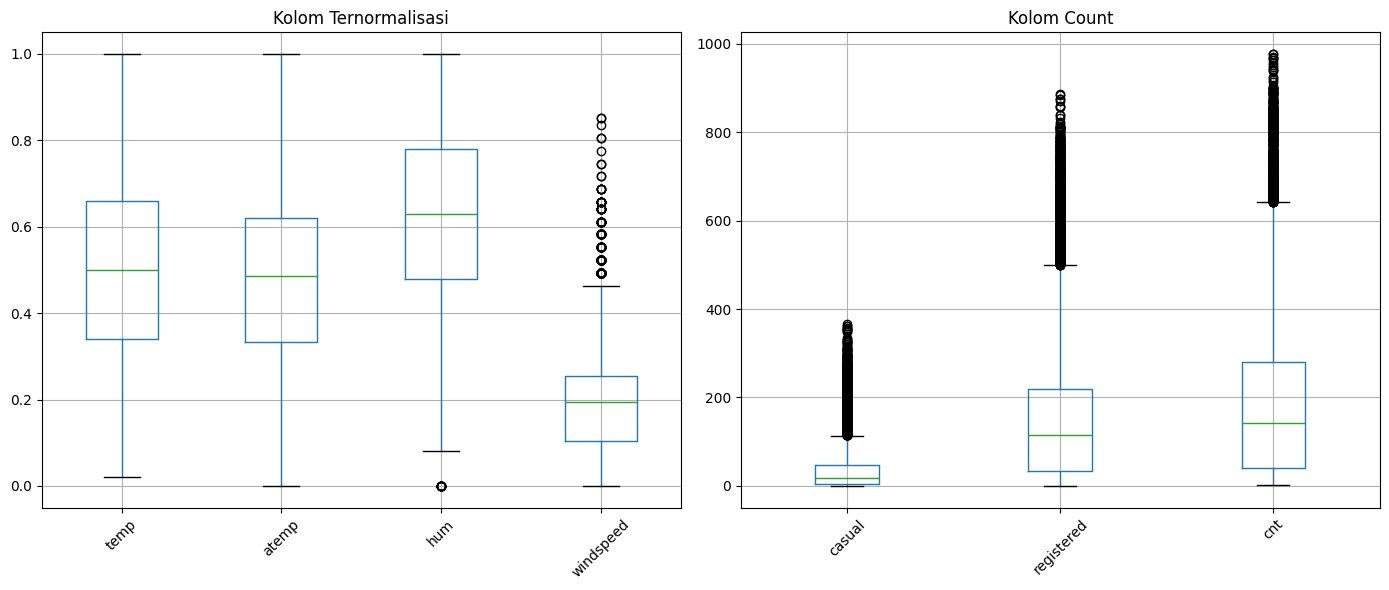

temp: 0 outlier
atemp: 0 outlier
hum: 22 outlier
windspeed: 342 outlier
casual: 1192 outlier
registered: 680 outlier
cnt: 505 outlier


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
175,176,2011-01-08,1,0,1,14,0,6,0,1,0.20,0.1667,0.32,0.4925,12,83,95
178,179,2011-01-08,1,0,1,17,0,6,0,1,0.16,0.1212,0.37,0.5522,5,64,69
194,195,2011-01-09,1,0,1,9,0,0,0,1,0.12,0.0758,0.46,0.5224,0,19,19
196,197,2011-01-09,1,0,1,11,0,0,0,1,0.16,0.1212,0.40,0.5224,2,47,49
265,266,2011-01-12,1,0,1,12,0,3,1,1,0.20,0.1515,0.47,0.5821,3,52,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17327,17328,2012-12-29,1,1,12,20,0,6,0,2,0.30,0.2424,0.56,0.5522,2,64,66
17328,17329,2012-12-29,1,1,12,21,0,6,0,2,0.28,0.2424,0.56,0.4925,4,56,60
17341,17342,2012-12-30,1,1,12,10,0,0,0,1,0.26,0.2121,0.41,0.5821,31,91,122
17343,17344,2012-12-30,1,1,12,12,0,0,0,1,0.28,0.2273,0.36,0.5821,47,97,144


In [ ]:
kolom_normalisasi = ['temp','atemp','hum','windspeed']
kolom_count = ['casual','registered','cnt']

fig, axes = plt.subplots(1, 2, figsize=(14,6))
hours_df[kolom_normalisasi].boxplot(ax=axes[0])
axes[0].set_title("Kolom Ternormalisasi")
axes[0].tick_params(axis='x', rotation=45)
hours_df[kolom_count].boxplot(ax=axes[1])
axes[1].set_title("Kolom Count")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for grup in [kolom_normalisasi, kolom_count]:
    for k in grup:
        Q1 = hours_df[k].quantile(0.25)
        Q3 = hours_df[k].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5*IQR
        batas_atas = Q3 + 1.5*IQR
        jumlah_outlier = ((hours_df[k] < batas_bawah) | (hours_df[k] > batas_atas)).sum()
        print(f"{k}: {jumlah_outlier} outlier")

Q1 = hours_df['windspeed'].quantile(0.25)
Q3 = hours_df['windspeed'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5*IQR
batas_atas = Q3 + 1.5*IQR

outlier_windspeed = hours_df[(hours_df['windspeed'] < batas_bawah) | (hours_df['windspeed'] > batas_atas)]
outlier_windspeed

**Steps to Take:**
- Untuk data yang tercatat pada tanggal 2011-03-10 pada hours_df dan days_df, nilai humiditas yang tercatat sebagai 0.000 pada semua jam yang tercatat perlu dilakukan imputasi. Imputasi yang dilakukan adalah menggunakan rata-rata hum pada jam yang sama dari 9 Maret 2011 dan 11 Maret 2011. Hal ini karena rata-rata hum dapat turun dan merusak analisis hubungan kelembapan dan jumlah penyewaan apabila hum tetap 0.000. Imputasi akan menggunakan data dari hari sekitarnya, bukan seluruh dataset karena kondisi cuaca cenderung berkolerasi dengan waktu yang berdekatan.

**Insight:** (Opsional)
- Berdasarkan data penyewaan per jam (hours_df), diketahui bahwa data penyewaan sepeda selama 2 tahun pada kondisi hujan deras, badai, dan salju (weathersit= 4) hanya sebanyak 3 data. Hal ini menunjukkan bahwa penyewa menghindari kendaraan yang tidak memiliki proteksi tambahan pada tubuh pada kondisi cuaca berat. Oleh karena data per hari kemungkinan mencatat dominan cuaca yang terjadi pada hari tertentu, weathersit=4 tidak muncul sama sekali dalam data.
- Pada hours_df, terlihat bahwa pada tiga kolom numerik: atemp, hum, dan windspeed, nilai minimum yang tercatat adalah 0.000. Nilai 0.000 pada kolom atemp masih bisa diterima karena sangat memungkinkan temperatur udara terasa seperti 0.000 pada kondisi tertentu. Akan tetapi, kedudukan nilai minimum hum dan windspeed (kondisi cuaca) perlu diinvestigasi lebih lanjut agar mengetahui apakah terdapat kesalahan pencatatan data selama proses pengumpulan data.
- Atemp 0.000 pada hours_df hanya terjadi pada 2 jam data pada hari yang sama dengan musim semi. Mengingat data temperatur dan atemp telah dinormalisasi menjadi angka dalam rentang 0-1, sangat memungkinkan bahwa temperatur udara bernilai 0.000 pada musim tersebut.
- Data humiditas pada hours_df dengan nilai 0.000 hanya muncul pada 1 tanggal saja, yaitu pada tanggal 10 Maret 2011. Dataset tidak menjelaskan bahwa ada fenomena tertentu pada tanggal tersebut (seperti Hurricane Sandy pada tanggal 2012-10-30) di tanggal 10 Maret 2011. Oleh karena itu, nilai hum 0.0 mencurigakan dan dapat diasumsi sebagai ketidakuratan data yang disebabkan oleh kegagalan pencatatan sensor pada hari itu.
- Nilai 0.000 untuk windspeed pada data tersebar di banyak tanggal yang berbeda. Mengingat data windspeed juga telah dinormalisasi menjadi angka dalam rentang 0-1, nilai windspeed dianggap valid.
- Pada dataset ini, ditemukan bahwa tidak semua tanggal memiliki 24 data jam (hours_df), dengan kasus terparah pada 30 Oktober 2012 yang hanya tercatat 11 jam (saat terjadi Hurricane Sandy). Akan tetapi, dengan mempertimbangkan kondisi operasional nyata (tidak ada penyewaan yang terjadi pada kondisi badai atau pada jam tertentu), kondisi ini tidak dianggap sebagai  kesalahan pencatatan. Hal ini juga didukung alasan bahwa analisis akan menggunakan agregasi rata-rata per jam sehingga setiap jam yang tercatat tetap dihitung sebagai observasi independed. Oleh karena itu, ketidaklengkapan ini tidak menimbulkan bias yang signifikan terhadap hasil akhir analisis.
- Terdapat data outlier pada kolom  hum, windspeed, dan cnt. Pada kolom hum, outlier merupakan data humiditas dengan nilai 0.0 yang tercatat pada satu tanggal saja (2011-03-10) tanpa penjelasan fenomena esktrim. Oleh karena itu, data pada hari tersebut yang muncul sebagai outlier pada data bisa dianggap sebagai data yang tidka akurat.
- Penyebaran outlier pada kolom windspeed cukup luas, tetapi tidak akan diganti karena didokumentaikan sebagai representasi kondisi cuaca berangin yang ekstrim. Nilai-nilai ini harus dipertahankan karena relevan untuk menjawab pertanyaaan analisis terkait pengaruh kondisi lingkungan terhadap jumlah penyewaan.
- Outlier pada kolom jumlah penyewaan (cnt, casual, registered) disebabkan karena jumlah penyewaan sepeda secara alami cenderung skewed karena disebabkan jam sibuk, seperti jam pulang kantor atau musim panas yang jauh lebih tinggi dari biasanya. Dengan demikian, outlier merepresentasikan pola nyata, bukan kesalahan data.

### Cleaning Data

#### Fixing inaccurate value problem

In [ ]:
#hours_df
reference = hours_df[hours_df['dteday'].isin(['2011-03-09', '2012-03-11'])]
mean_per_jam = reference.groupby('hr')['hum'].mean()
new_hum = (hours_df['dteday'] == '2011-03-10') & (hours_df['hum'] == 0)

for h in hours_df.loc[new_hum, 'hr']:
  hours_df.loc[new_hum & (hours_df['hr'] == h), 'hum'] = mean_per_jam[h]

print(hours_df[hours_df['dteday'] == '2011-03-10'][['dteday', 'hr', 'hum']])


          dteday  hr    hum
1551  2011-03-10   0  0.545
1552  2011-03-10   1  0.520
1553  2011-03-10   2  0.520
1554  2011-03-10   5  0.705
1555  2011-03-10   6  0.775
1556  2011-03-10   7  0.780
1557  2011-03-10   8  0.780
1558  2011-03-10   9  0.735
1559  2011-03-10  10  0.620
1560  2011-03-10  11  0.595
1561  2011-03-10  12  0.565
1562  2011-03-10  13  0.585
1563  2011-03-10  14  0.535
1564  2011-03-10  15  0.500
1565  2011-03-10  16  0.535
1566  2011-03-10  17  0.515
1567  2011-03-10  18  0.525
1568  2011-03-10  19  0.535
1569  2011-03-10  20  0.670
1570  2011-03-10  21  0.735
1571  2011-03-10  22  0.735
1572  2011-03-10  23  0.715


In [ ]:
#days_df
mean_hum = days_df[days_df['dteday'].isin(['2011-03-09', '2011-03-11'])]['hum'].mean()
days_df.loc[days_df['dteday']=='2011-03-10', 'hum'] = mean_hum

print(days_df[days_df['dteday']=='2011-03-10'][['dteday', 'hum']])

        dteday       hum
68  2011-03-10  0.712491


In [ ]:
#cek data hum=0
print("hum = 0 in hours_df:", (hours_df['hum']==0).sum())
print("hum = 0 in days_df:", (days_df['hum']==0).sum())

hum = 0 in hours_df: 0
hum = 0 in days_df: 0


**Insight:** (Opsional)
- Setelah dilakukan imputasi, nilai hum yang ebrnilai 0 pada tanggal 10 Maret 2011 digantikan dengan nilai estimasi berdasarkan rata-rata humiditas dari tanggal 9 Maret dan 11 Maret 2011. Berdasarkan verifikasi yang telah dilakukan terhadap kedua dataframe, tidak ada nilai hum yang bernilai 0.

## Exploratory Data Analysis (EDA)

### Explore Kombinasi Hari & Jam dengan Rata-rata Penyewaan Tertinggi

In [ ]:
day_label = {0:'Sunday', 1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday', 5:'Friday', 6:'Saturday'}
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

hari_jam_sewa_df = hours_df.groupby(['weekday', 'hr']).agg(
    **{'Rata-rata Penyewaan':('cnt', 'mean')}
).reset_index()
hari_jam_sewa_df = hari_jam_sewa_df.rename(columns={'weekday': 'Hari', 'hr':'Jam'})
hari_jam_sewa_df['Rata-rata Penyewaan'] = hari_jam_sewa_df['Rata-rata Penyewaan'].round(1)
hari_jam_sewa_df['Hari'] = hari_jam_sewa_df['Hari'].map(day_label)
hari_jam_sewa_df['Hari'] = pd.Categorical(hari_jam_sewa_df['Hari'], categories=day_order, ordered=True)
hari_jam_sewa_df.sort_values(by='Rata-rata Penyewaan', ascending=False)


,Hari,Jam,Rata-rata Penyewaan
65,Tuesday,17,544.3
113,Thursday,17,527.3
66,Tuesday,18,517.6
89,Wednesday,17,513.1
41,Monday,17,502.4
...,...,...,...
52,Tuesday,4,5.1
99,Thursday,3,5.1
76,Wednesday,4,5.0
75,Wednesday,3,4.9


In [ ]:
rata2_per_hari = days_df.groupby('weekday').agg(
    **{'Rata-rata Penyewaan': ('cnt', 'mean')}
).reset_index()
rata2_per_hari = rata2_per_hari.rename(columns={'weekday': 'Hari'})
rata2_per_hari['Hari'] = rata2_per_hari['Hari'].map(day_label)
rata2_per_hari = rata2_per_hari.sort_values(by='Rata-rata Penyewaan', ascending=False)
rata2_per_hari

,Hari,Rata-rata Penyewaan
5,Friday,4690.288462
4,Thursday,4667.259615
6,Saturday,4550.542857
3,Wednesday,4548.538462
2,Tuesday,4510.663462
1,Monday,4338.123810
0,Sunday,4228.828571


In [ ]:
jam_max = hari_jam_sewa_df.loc[hari_jam_sewa_df.groupby('Hari', observed=True)['Rata-rata Penyewaan'].idxmax()]
jam_max = jam_max.rename(columns={'Jam':'Jam Tersibuk','Rata-rata Penyewaan':'Penyewaan Tertinggi'}).reset_index(drop=True)

jam_min = hari_jam_sewa_df.loc[hari_jam_sewa_df.groupby('Hari', observed=True)['Rata-rata Penyewaan'].idxmin()]
jam_min = jam_min.rename(columns={'Jam':'Jam Tersepi','Rata-rata Penyewaan':'Penyewaan Terendah'}).reset_index(drop=True)

ringkasan_per_hari = jam_max.merge(jam_min, on='Hari')
ringkasan_per_hari

,Hari,Jam Tersibuk,Penyewaan Tertinggi,Jam Tersepi,Penyewaan Terendah
0,Sunday,13,374.9,5,8.7
1,Monday,17,502.4,3,5.1
2,Tuesday,17,544.3,3,4.2
3,Wednesday,17,513.1,3,4.9
4,Thursday,17,527.3,3,5.1
5,Friday,17,492.4,4,6.1
6,Saturday,13,385.4,4,7.7


In [ ]:
best_three = rata2_per_hari.head(3)['Hari'].tolist()
best_three_sewa = hari_jam_sewa_df[hari_jam_sewa_df['Hari'].isin(best_three)]
best_three_sewa.sort_values(by='Rata-rata Penyewaan', ascending=False)

,Hari,Jam,Rata-rata Penyewaan
113,Thursday,17,527.3
114,Thursday,18,502.1
137,Friday,17,492.4
104,Thursday,8,488.6
128,Friday,8,462.3
...,...,...,...
148,Saturday,4,7.7
123,Friday,3,6.6
124,Friday,4,6.1
100,Thursday,4,5.3


**Insight:** (Opsional)
- Jam 17:00 merupakan jam dengan jumlah penyewaan sepeda tertinggi pada 5 hari (Senin, Selasa, Rabu, Kamis, Jumat) yang merupakan weekday. Hal ini mengindikasikan bahwa jam 17:00 adalah jam sibuk saat orang-orang membutuhkan transportasi untuk pulang kantor atau alasan lainnya yang konsisten terjadi selama weekdays.
- Pada hari weekend, jumlah penyewaan tertinggi ditemukan pada pukul 13:00 siang. Hal ini semakin mendukung kesimpulan bahwa pola weekend didorong oleh aktivitas rekreasi di siang hari, sedangkan untuk weekdays terdapat pola commuting yang lonjakannya terjadi pada jam pulang kantor.
- Jam paling sepi penyewa sepeda ada pada jam 3-5 pagi. Hal ini menunjukkan kondisi realita bahwa jam 3-5 merupakan jam tidur atau hampir tidak ada aktivitas di luar tempat tinggal yang sedang terjadi.
- Jumat merupakan hari dengan jumlah penyewaan paling tinggi, sedangkan Minggu berada di peringkat terendah.
- Walaupun Jumat memiliki jumlah penyewaan tertinggi secara total, pada jam puncak di hari Jumat, yaitu jam 17:00, jumlah penyewaan tetap lebih tinggi di hari Selasa dan Kamis.

### Explore Pengaruh Cuaca Terhadap Jumlah Penyewaan Sepeda Selama 2011-2012

In [ ]:
weather_labels = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}

weather_cnt_df = hours_df.groupby('weathersit')['cnt'].agg(
    Jumlah_Data='count',
    Rata_rata='mean',
    Median='median',
    Std_Deviasi='std',
    Min='min',
    Max='max',
    Total_Sewa='sum'
).round(1).reset_index()
weather_cnt_df = weather_cnt_df.rename(columns={'weathersit':'Kondisi Cuaca'})
weather_cnt_df['Kondisi Cuaca'] = weather_cnt_df['Kondisi Cuaca'].map(weather_labels)
weather_cnt_df

,Kondisi Cuaca,Jumlah_Data,Rata_rata,Median,Std_Deviasi,Min,Max,Total_Sewa
0,Clear,11413,204.9,159.0,189.5,1,977,2338173
1,Mist,4544,175.2,133.0,165.4,1,957,795952
2,Light Rain/Snow,1419,111.6,63.0,133.8,1,891,158331
3,Heavy Rain/Snow,3,74.3,36.0,77.9,23,164,223


In [ ]:
weather_penyewa_df = hours_df.groupby('weathersit')[['casual','registered']].mean().round(1).reset_index()
weather_penyewa_df = weather_penyewa_df.rename(columns={'weathersit':'Kondisi Cuaca','casual':'Rata-rata Casual','registered':'Rata-rata Registered'})
weather_penyewa_df['Kondisi Cuaca'] = weather_penyewa_df['Kondisi Cuaca'].map(weather_labels)
weather_penyewa_df

,Kondisi Cuaca,Rata-rata Casual,Rata-rata Registered
0,Clear,40.5,164.3
1,Mist,29.6,145.6
2,Light Rain/Snow,16.1,95.5
3,Heavy Rain/Snow,2.7,71.7


**Insight:** (Opsional)
- Jumlah penyewaan sepeda dipengaruhi oleh cuaca. Cuaca cerah memiliki jumlah penyewaan paling tinggi sedangkan cuaca ekstrem berada di peringkat terendah.
- Standar deviasi turun dari 189.5 (clear) ke 165.4 (mist) ke 133.8 (light rain/snow). Hal ini berarti saat cuaca cerah, jumlah penyewaan per jam jauh lebih fluktuatif, bisa sangat ramai atau sepi. Pada saat cuaca memburuk, jumlah sewa cenderung konsisten rendah.
- Penurunan jumlah sewa yang casual dari 40 (clear) ke 2.7 (heavy rain.snow) setara dengan turun 90%. Di sisi lain, penurunan registered lebih sedikit, yaitu di atas 50%. Hal inni bsia disebabkan pengguna registered tetap menyewa meski cuaca emburuk, sementara penyewa casual jauh lebih mudah membatalkan rencana sewa jika cuaca sedang jelek.
- Untuk setiap kondisi cuaca, penyewaan jenis registered tetap mendominasi.


### Explore Tren Pengguna Casual VS Registered per Bulan Sepanjang 2011–2012  dan Pergeseran antar Musim

In [ ]:
year_label = {0:'2011', 1:'2012'}
month_label = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
season_label = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}

tren_bulanan = days_df.groupby(['yr','mnth']).agg(
    Total_Casual=('casual','sum'),
    Total_Registered=('registered','sum'),
    Total_Cnt=('cnt','sum')
).reset_index()

tren_bulanan['Proporsi_Casual (%)'] = (tren_bulanan['Total_Casual']/tren_bulanan['Total_Cnt']*100).round(1)
tren_bulanan['Proporsi_Registered (%)'] = (tren_bulanan['Total_Registered']/tren_bulanan['Total_Cnt']*100).round(1)

tren_bulanan['yr'] = tren_bulanan['yr'].map(year_label)
tren_bulanan['mnth'] = tren_bulanan['mnth'].map(month_label)
tren_bulanan = tren_bulanan.rename(columns={'yr':'Tahun','mnth':'Bulan'})

tahun_asli = tren_bulanan['Tahun'].map({0:2011, 1:2012})
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
tren_bulanan['Bulan'] = pd.Categorical(tren_bulanan['Bulan'], categories=month_order, ordered=True)

tren_bulanan

,Tahun,Bulan,Total_Casual,Total_Registered,Total_Cnt,Proporsi_Casual (%),Proporsi_Registered (%)
0,2011,January,3073,35116,38189,8.0,92.0
1,2011,February,6242,41973,48215,12.9,87.1
2,2011,March,12826,51219,64045,20.0,80.0
3,2011,April,22346,72524,94870,23.6,76.4
4,2011,May,31050,104771,135821,22.9,77.1
5,2011,June,30612,112900,143512,21.3,78.7
6,2011,July,36452,104889,141341,25.8,74.2
7,2011,August,28842,107849,136691,21.1,78.9
8,2011,September,26545,100873,127418,20.8,79.2
9,2011,October,25222,98289,123511,20.4,79.6


In [ ]:
tabel_dominasi = days_df.groupby('season').agg(
    Total_Casual=('casual','sum'),
    Total_Registered=('registered','sum')
).reset_index()
tabel_dominasi['Rasio_Registered_per_Casual'] = (tabel_dominasi['Total_Registered']/tabel_dominasi['Total_Casual']).round(2)
tabel_dominasi['season'] = tabel_dominasi['season'].map(season_label)
tabel_dominasi = tabel_dominasi.rename(columns={'season':'Musim'})
tabel_dominasi = tabel_dominasi.sort_values('Rasio_Registered_per_Casual')
tabel_dominasi

,Musim,Total_Casual,Total_Registered,Rasio_Registered_per_Casual
1,Summer,203522,715067,3.51
2,Fall,226091,835038,3.69
3,Winter,129782,711831,5.48
0,Spring,60622,410726,6.78


**Insight:** (Opsional)
- Pola musiman pada tahun 2011 terulang pada tahun 2012. Hal ini dapat dilihat dari kenaikan proporsi casual (8%, Januari 2011) menjadi 21.3% di Juni 2011, dan pada 2012 juga terjadi hal yang sama (kenaikan dari 9%, Januari 2012, menjadi 21.3%, Juni 2012. Kenaikan dan penurunan yang identik apda kedua tahun mengindikasikan bahwa bentuk kurva kedua tahun kurang lebih sama, hanya saja berbeda pada volumnya.
- Volum penyewaan sepeda pada tahun 2012 lebih tinggi dibanding dengan tahun 2011 pada bulan yang sama. Misal, jumlah casual di bulan Januari tahun 2011 sebanyak 3073, tetapi pada tahun 2012 sebanyak 8969. Hal ini menandakan bahwa ada pertumbuhan bisnis penyewaan sepeda di tahun 2012. Dengan demikian, kurva untuk tahun 2012 harus lebih tinggi dibanding dengan tahun 2011.
- Perbedaan antara casual dan registered paling kecil saat bulan Summer, dan paling besar saat Spring, yakni hampir 2x lipat dibandingkan perbedaan saat Summer. Hal ini sekaligus mengindikasikan bahwa Summer merupakan kondisi yang cocok untuk bersepeda, sedangkan di kondisi dingin, penyewaan secara casual lebih sedikit.




### Explore Pengaruh Kondisi Lingkungan (temp, hum, windspeed) Terhadap Penyewaan Sepeda Selama 2011-2012

In [ ]:
hours_df['temp_celcius'] = (hours_df['temp']*41).round(1)
hours_df['hum_percent'] = (hours_df['hum']*100).round(1)
hours_df['windspeed_kmh'] = (hours_df['windspeed']*67).round(1)

label_kategori = ['Rendah','Sedang','Tinggi','Sangat Tinggi']
hours_df['temp_group'] = pd.qcut(hours_df['temp_celcius'], q=4, labels=label_kategori)
hours_df['hum_group'] = pd.qcut(hours_df['hum_percent'], q=4, labels=label_kategori)
hours_df['windspeed_group'] = pd.qcut(hours_df['windspeed_kmh'], q=4, labels=label_kategori, duplicates='drop')

tabel_temp = hours_df.groupby('temp_group', observed=True).agg(
    Jumlah_Data=('cnt','count'),
    Rentang_Min=('temp_celcius','min'),
    Rentang_Max=('temp_celcius','max'),
    Rata_rata_Casual=('casual','mean'),
    Rata_rata_Registered=('registered','mean'),
    Rata_rata_Penyewaan=('cnt','mean')
).round(1)
tabel_temp

,Jumlah_Data,Rentang_Min,Rentang_Max,Rata_rata_Casual,Rata_rata_Registered,Rata_rata_Penyewaan
temp_group,,,,,,
Rendah,4770,0.8,13.9,8.6,89.0,97.7
Sedang,4090,14.8,20.5,27.4,141.6,169.0
Tinggi,4795,21.3,27.1,42.4,171.9,214.3
Sangat Tinggi,3724,27.9,41.0,70.7,226.9,297.6


In [ ]:
tabel_hum = hours_df.groupby('hum_group', observed=True).agg(
    Jumlah_Data=('cnt','count'),
    Rentang_Min=('hum_percent','min'),
    Rentang_Max=('hum_percent','max'),
    Rata_rata_Casual=('casual','mean'),
    Rata_rata_Registered=('registered','mean'),
    Rata_rata_Penyewaan=('cnt','mean')
).round(1)
tabel_hum

,Jumlah_Data,Rentang_Min,Rentang_Max,Rata_rata_Casual,Rata_rata_Registered,Rata_rata_Penyewaan
hum_group,,,,,,
Rendah,4547,8.0,48.0,59.6,205.9,265.5
Sedang,4248,49.0,63.0,39.3,170.3,209.5
Tinggi,4271,64.0,78.0,28.8,140.7,169.5
Sangat Tinggi,4313,79.0,100.0,13.8,95.6,109.4


In [ ]:
tabel_windspeed = hours_df.groupby('windspeed_group', observed=True).agg(
    Jumlah_Data=('cnt','count'),
    Rentang_Min=('windspeed_kmh','min'),
    Rentang_Max=('windspeed_kmh','max'),
    Rata_rata_Casual=('casual','mean'),
    Rata_rata_Registered=('registered','mean'),
    Rata_rata_Penyewaan=('cnt','mean')
).round(1)
tabel_windspeed

,Jumlah_Data,Rentang_Min,Rentang_Max,Rata_rata_Casual,Rata_rata_Registered,Rata_rata_Penyewaan
windspeed_group,,,,,,
Rendah,5222,0.0,7.0,28.0,131.5,159.5
Sedang,5090,9.0,13.0,35.0,155.9,190.9
Tinggi,2808,15.0,17.0,42.2,170.6,212.8
Sangat Tinggi,4259,19.0,57.0,41.6,167.5,209.1


**Insight:** (Opsional)
- Kondisi yang paling mendukung penyewaan sepeda adalah saat temperatur panas (temperatur sangat tinggi), tidak lembab (humiditas rendah), dan saat angin cukup kencang (windspeed tinggi). Sebaliknya, penyewaan paling dikit terjadi saat tempertaur dingin (temperatur rendah), kondisi lingkungan terasa lembab (humiditas sangat tinggi), dan angin sangat sedikit (windspeed rendah). Pola ini konsisten terlihat pada penyewa casual dan registered, tetapi registered tetap memiliki rata-rata angka yang lebih tinggi dibandingkan casual pada semua kondisi.
- Di antara 3 variabel tersebut, yang memiliki pengaruh paling signifikan terhadap jumlah penyewaan sepeda adalah temperatur. Hal ini dapat dilihat bahwa saat temperatur berubah dari rendah ek sangat tinggi, jumlah penyewaan meningkat hampir 3 kali lipat.
- Windspeed memiliki pengaruh yang paling lemah karena perbedaan jumlah penyewaan antar kategori windspeed yang berbeda tidak sebesar pengaruh temperatur dan humiditas. Bahkan, jumlah penyewaan tertinggi saat kecepatan angin di kategori tinggi, bukan sangat tinggi. Hal ini mengindikasikan bahwa angin membantu kenyamanan bersepeda hanya sampai batas tertentu, setelah itu mulai melemah.
- Temperatur dan windspeed menunjukkan korelasi positif terhadap jumlah penyewaan, yakni semakin tinggi temperatur dan windspeed, semakin tinggi rata-rata penyewaannya. Sebaliknya, humiditas menunjukkan korelasi negatif (berlawanan arah), yakni semakin tinggi kelembapan, semkain rendah rata-rata penyewaan.






## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada kombinasi hari dan jam apa rata-rata jumlah penyewaan tertinggi tercatat selama 2011–2012?

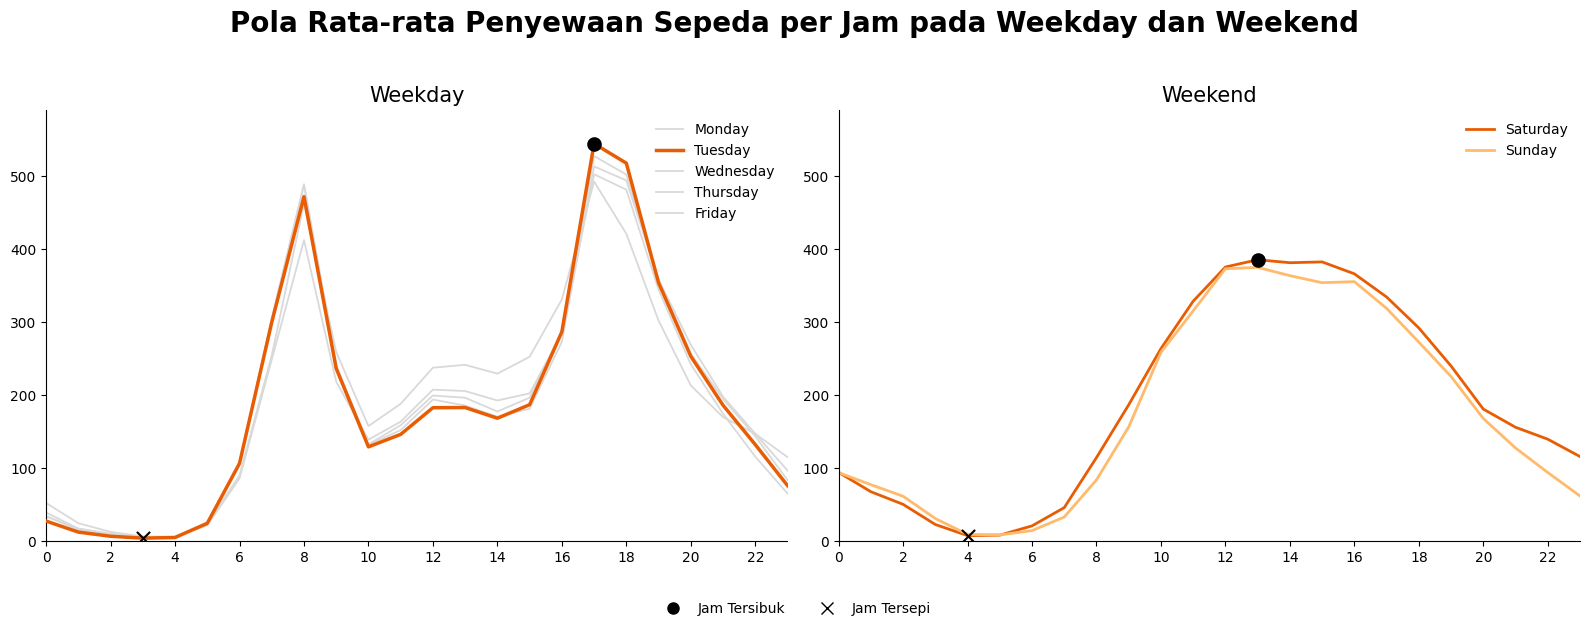

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle("Pola Rata-rata Penyewaan Sepeda per Jam pada Weekday dan Weekend", fontsize=20, fontweight="bold")

weekday_list = ['Monday','Tuesday','Wednesday','Thursday','Friday']
weekday_df = hari_jam_sewa_df[hari_jam_sewa_df['Hari'].isin(weekday_list)]
hari_tertinggi = weekday_df.groupby('Hari', observed=True)['Rata-rata Penyewaan'].max().idxmax()

for hari in weekday_list:
    data_hari = hari_jam_sewa_df[hari_jam_sewa_df['Hari']==hari]
    if hari == hari_tertinggi:
        axes[0].plot(data_hari['Jam'], data_hari['Rata-rata Penyewaan'], label=hari, linewidth=2.5, color='#E85D04', zorder=3)
    else:
        axes[0].plot(data_hari['Jam'], data_hari['Rata-rata Penyewaan'], label=hari, linewidth=1.3, color='#D9D9D9', zorder=2)

baris_max = weekday_df.loc[[weekday_df['Rata-rata Penyewaan'].idxmax()]]
baris_min = weekday_df.loc[[weekday_df['Rata-rata Penyewaan'].idxmin()]]

axes[0].scatter(baris_max['Jam'], baris_max['Rata-rata Penyewaan'], color='black', s=90, zorder=5)
axes[0].scatter(baris_min['Jam'], baris_min['Rata-rata Penyewaan'], color='black', marker='x', s=90, zorder=5)
axes[0].set_title('Weekday', fontsize=15)
axes[0].margins(x=0)
axes[0].set_ylim(0, 590)
axes[0].set_xticks(range(0,24,2))
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

weekend_list = ['Saturday','Sunday']
weekend_df = hari_jam_sewa_df[hari_jam_sewa_df['Hari'].isin(weekend_list)]
hari_tertinggi_weekend = weekend_df.groupby('Hari', observed=True)['Rata-rata Penyewaan'].max().idxmax()

for hari in weekend_list:
    data_hari = hari_jam_sewa_df[hari_jam_sewa_df['Hari']==hari]
    warna = '#E85D04' if hari == hari_tertinggi_weekend else '#FFBA6B'
    axes[1].plot(data_hari['Jam'], data_hari['Rata-rata Penyewaan'], label=hari, linewidth=2, color=warna)

baris_max_w = weekend_df.loc[[weekend_df['Rata-rata Penyewaan'].idxmax()]]
baris_min_w = weekend_df.loc[[weekend_df['Rata-rata Penyewaan'].idxmin()]]

axes[1].scatter(baris_max_w['Jam'], baris_max_w['Rata-rata Penyewaan'], color='black', s=90, zorder=5)
axes[1].scatter(baris_min_w['Jam'], baris_min_w['Rata-rata Penyewaan'], color='black', marker='x', s=90, zorder=5)
axes[1].set_title('Weekend', fontsize=15)
axes[1].margins(x=0)
axes[1].set_ylim(0, 590)
axes[1].set_xticks(range(0,24,2))
axes[1].yaxis.tick_left()
axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

marker_tinggi = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=8, label='Jam Tersibuk')
marker_rendah = mlines.Line2D([], [], color='black', marker='x', linestyle='None', markersize=8, label='Jam Tersepi')
fig.legend(handles=[marker_tinggi, marker_rendah], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), frameon=False)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()

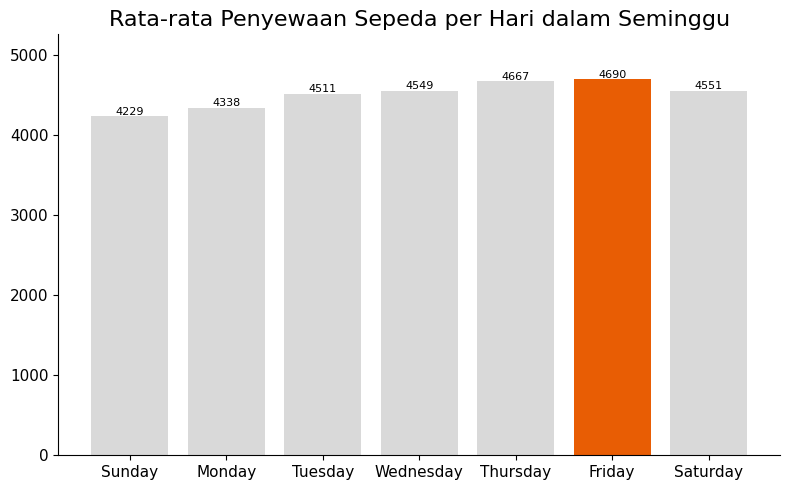

In [ ]:
urutan_hari = ['Sunday', 'Monday', 'Tuesday', 'Wednesday',
               'Thursday', 'Friday', 'Saturday']

rata2_per_hari['Hari'] = pd.Categorical(
    rata2_per_hari['Hari'],
    categories=urutan_hari,
    ordered=True
)
rata2_per_hari = rata2_per_hari.sort_values('Hari').reset_index(drop=True)
hari_tertinggi = rata2_per_hari.loc[rata2_per_hari['Rata-rata Penyewaan'].idxmax(), 'Hari']
warna_bar = ['#E85D04' if h==hari_tertinggi else '#D9D9D9' for h in rata2_per_hari['Hari']]

plt.figure(figsize=(8,5))
bars = plt.bar(rata2_per_hari['Hari'], rata2_per_hari['Rata-rata Penyewaan'], color=warna_bar)
plt.title('Rata-rata Penyewaan Sepeda per Hari dalam Seminggu', fontsize=16)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0,rata2_per_hari['Rata-rata Penyewaan'].max()*1.12)

for bar in bars:
    tinggi = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, tinggi+20, f'{tinggi:.0f}', ha='center', fontsize=8)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana kondisi cuaca (weatehrsit) memengaruhi total penyewaan sepanjang 2011–2012?

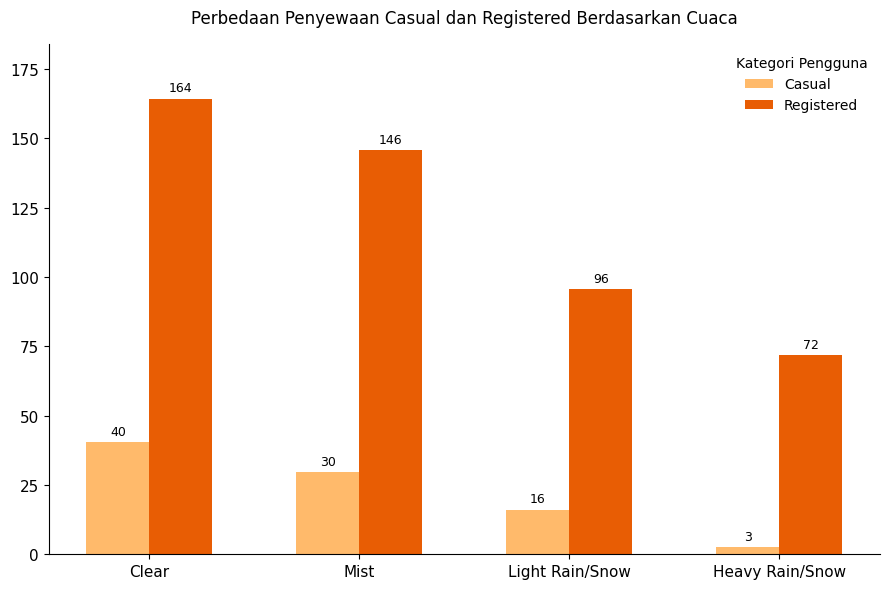

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(weather_penyewa_df))
width = 0.30

bars_casual = ax.bar(x - width/2, weather_penyewa_df['Rata-rata Casual'], width, label='Casual', color='#FFBA6B')
bars_registered = ax.bar(x + width/2, weather_penyewa_df['Rata-rata Registered'], width, label='Registered', color='#E85D04')

# Data label di atas tiap bar
for bars in [bars_casual, bars_registered]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_title('Perbedaan Penyewaan Casual dan Registered Berdasarkan Cuaca',
             fontsize=12, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(weather_penyewa_df['Kondisi Cuaca'])
ax.set_xlabel('')
ax.set_ylabel('')
ax.legend(title='Kategori Pengguna', loc='upper right', frameon=False)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.set_ylim(0, weather_penyewa_df[['Rata-rata Casual','Rata-rata Registered']].to_numpy().max()*1.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Pertanyaan 3: Bagaimana proporsi dan tren pengguna casual vs registered per bulan sepanjang 2011–2012, dan apakah proporsinya bergeser antar musim (season)?

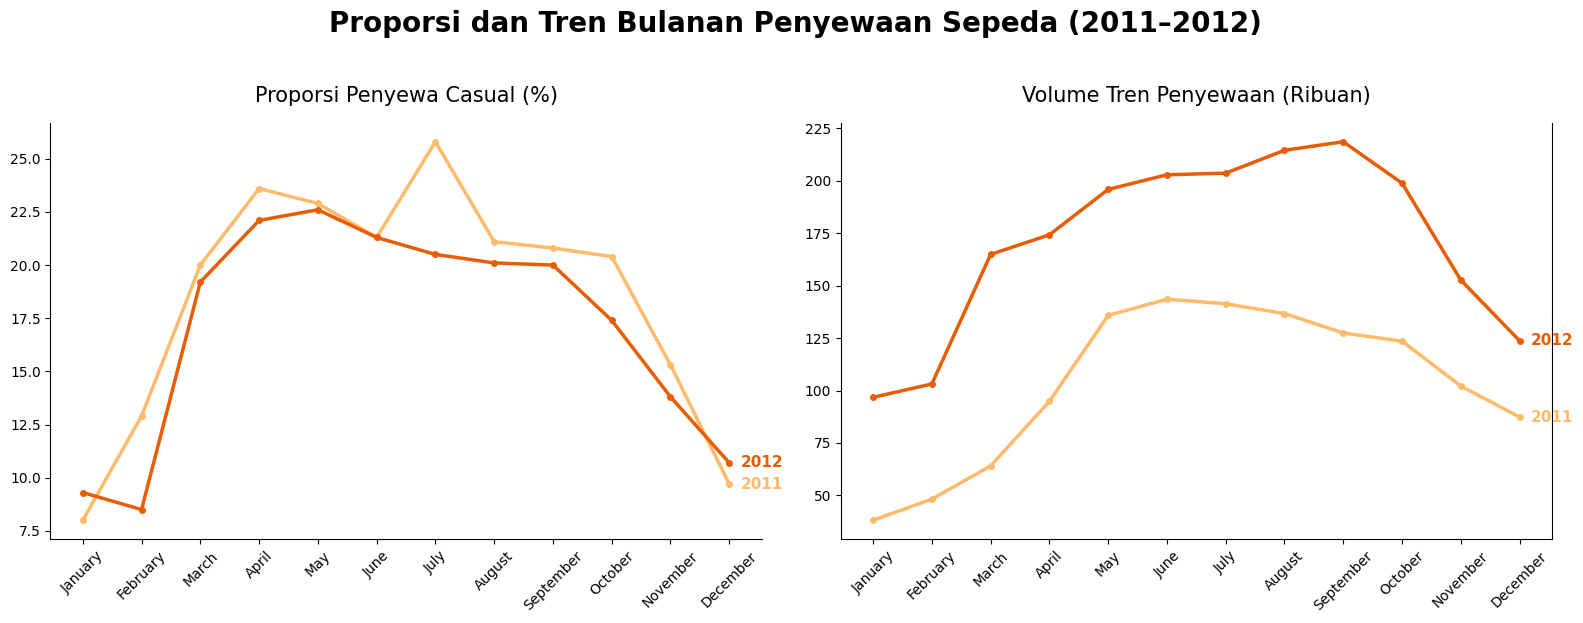

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
warna_tahun = {'2011':'#FFBA6B', '2012':'#E85D04'}

for tahun in ['2011','2012']:
    data_tahun = tren_bulanan[tren_bulanan['Tahun']==tahun].sort_values('Bulan')
    axes[0].plot(data_tahun['Bulan'], data_tahun['Proporsi_Casual (%)'], linewidth=2.5, color=warna_tahun[tahun], marker='o', markersize=4)
    axes[0].annotate(tahun, xy=(data_tahun['Bulan'].iloc[-1], data_tahun['Proporsi_Casual (%)'].iloc[-1]), xytext=(8, 0), textcoords='offset points', color=warna_tahun[tahun], fontsize=11, fontweight='bold', va='center', ha='left')

axes[0].set_title('Proporsi Penyewa Casual (%)', fontsize=15, pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for tahun in ['2011','2012']:
    data_tahun = tren_bulanan[tren_bulanan['Tahun']==tahun].sort_values('Bulan')
    axes[1].plot(data_tahun['Bulan'], data_tahun['Total_Cnt'], linewidth=2.5, color=warna_tahun[tahun], marker='o', markersize=4)
    axes[1].annotate(tahun, xy=(data_tahun['Bulan'].iloc[-1], data_tahun['Total_Cnt'].iloc[-1]), xytext=(8, 0), textcoords='offset points', color=warna_tahun[tahun], fontsize=11, fontweight='bold', va='center', ha='left')
axes[1].set_title('Volume Tren Penyewaan (Ribuan)', fontsize=15, pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}'))
axes[1].spines['top'].set_visible(False)

fig.suptitle('Proporsi dan Tren Bulanan Penyewaan Sepeda (2011–2012)', fontsize=20, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

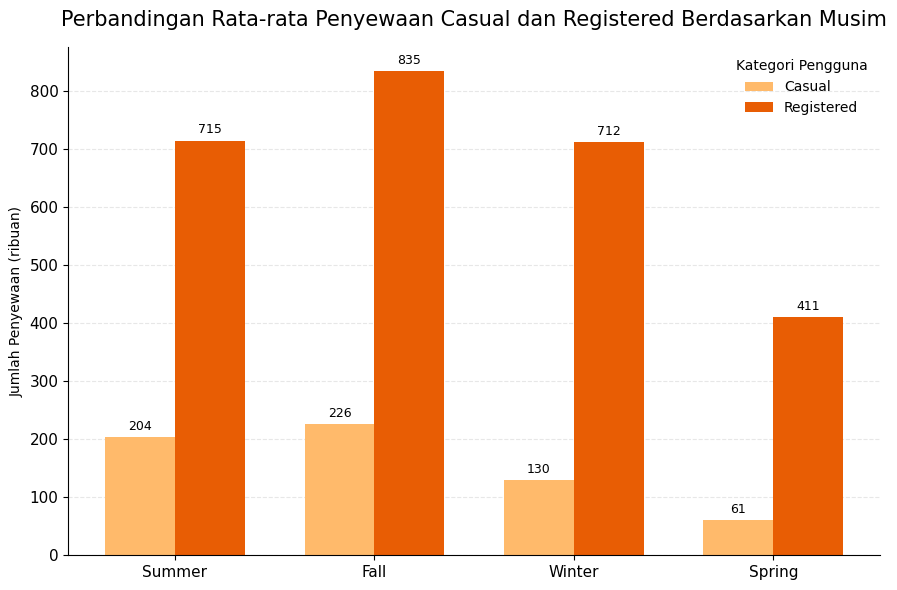

In [ ]:
tabel_dominasi_sorted = tabel_dominasi.sort_values('Rasio_Registered_per_Casual').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9,6))
x = np.arange(len(tabel_dominasi_sorted))
width = 0.35

bars_casual = ax.bar(x - width/2, tabel_dominasi_sorted['Total_Casual'], width,
                      label='Casual', color='#FFBA6B')
bars_registered = ax.bar(x + width/2, tabel_dominasi_sorted['Total_Registered'], width,
                          label='Registered', color='#E85D04')
for bars in [bars_casual, bars_registered]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height/1000:.0f}',
            xy=(bar.get_x()+bar.get_width()/2, height),
            xytext=(0,3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=9
        )

ax.set_title('Perbandingan Rata-rata Penyewaan Casual dan Registered Berdasarkan Musim', fontsize=15, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(tabel_dominasi_sorted['Musim'])
ax.legend(title='Kategori Pengguna', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1000:.0f}'))
ax.set_ylabel('Jumlah Penyewaan (ribuan)', fontsize=10)

plt.tight_layout()
plt.show()

### Pertanyaan 4: Bagaimana kondisi lingkungan, seperti temperatur (temp/atemp), hum, dan windspeed memengaruhi penyewaan selama 2011–2012?

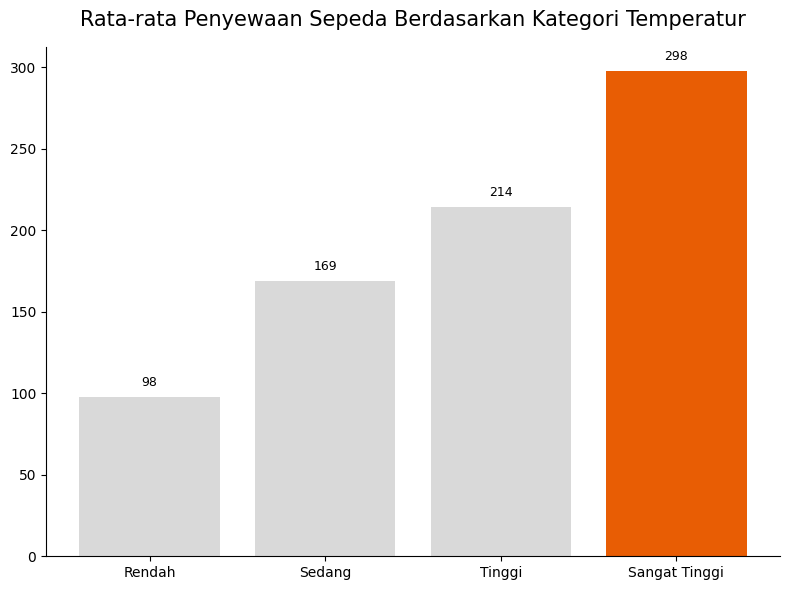

In [ ]:
nilai_temp = tabel_temp['Rata_rata_Penyewaan'].values
idx_max_temp = np.argmax(nilai_temp)
warna_temp = ['#E85D04' if i == idx_max_temp else '#D9D9D9' for i in range(len(nilai_temp))]

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(label_kategori, nilai_temp, color=warna_temp)

for bar in bars:
    tinggi = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, tinggi + 5, f'{tinggi:.0f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Rata-rata Penyewaan Sepeda Berdasarkan Kategori Temperatur', fontsize=15, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

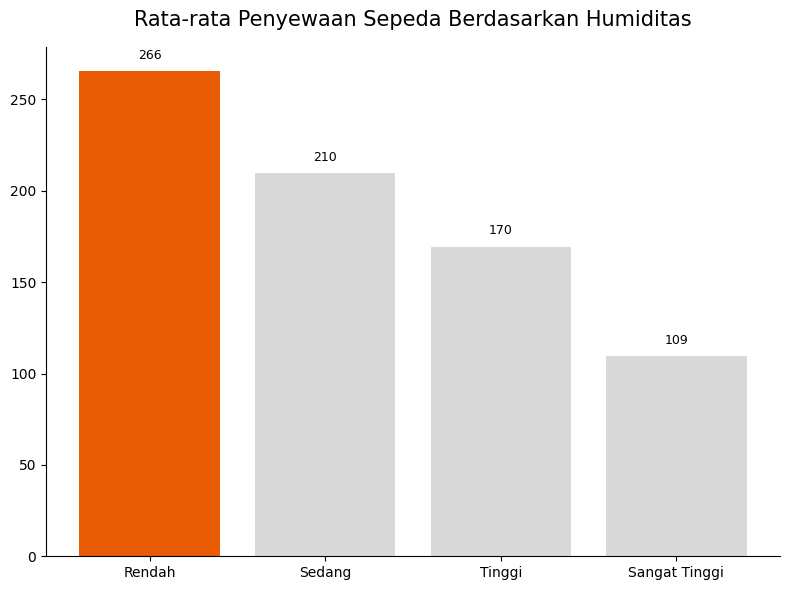

In [ ]:
nilai_hum = tabel_hum['Rata_rata_Penyewaan'].values
idx_max_hum = np.argmax(nilai_hum)
warna_hum = ['#E85D04' if i == idx_max_hum else '#D9D9D9' for i in range(len(nilai_hum))]

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(label_kategori, nilai_hum, color=warna_hum)

for bar in bars:
    tinggi = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, tinggi + 5, f'{tinggi:.0f}',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Rata-rata Penyewaan Sepeda Berdasarkan Humiditas', fontsize=15, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

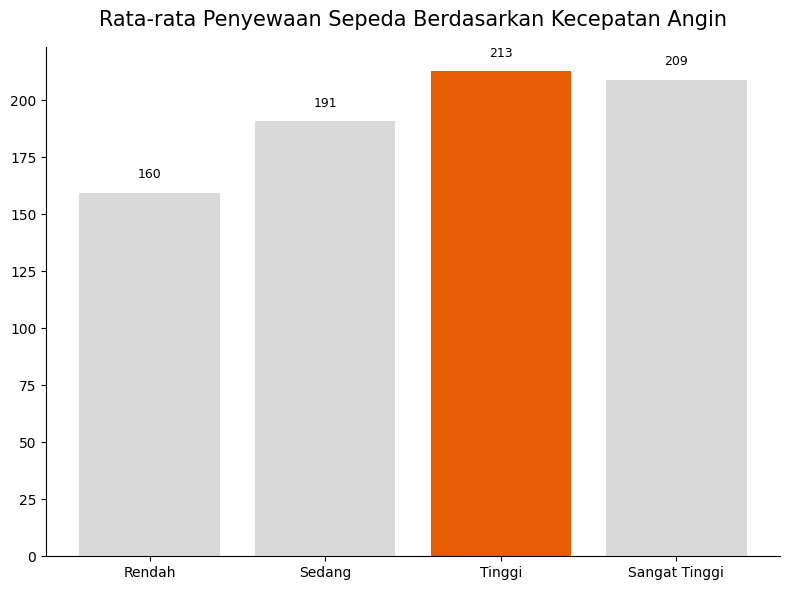

In [ ]:
nilai_windspeed = tabel_windspeed['Rata_rata_Penyewaan'].values
idx_max_windspeed = np.argmax(nilai_windspeed)
warna_windspeed = ['#E85D04' if i == idx_max_windspeed else '#D9D9D9' for i in range(len(nilai_windspeed))]

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(label_kategori, nilai_windspeed, color=warna_windspeed)

for bar in bars:
    tinggi = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, tinggi + 5, f'{tinggi:.0f}',
            ha='center', va='bottom', fontsize=9)

ax.set_title('Rata-rata Penyewaan Sepeda Berdasarkan Kecepatan Angin', fontsize=15, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Jumat merupakan hari dengan rata-rata penyewaan tertinggi, diikuti Kamis, dan Sabtu, sementara Minggu adalah hari paling sepi. Pada weekdays, jam 17:00 merupakan jam yang secara konsistem menjadi jam tersibuk dengan banyak penyewaan untuk hari yang berbeda-beda, dengan Selasa jam 17:00 senbagai pemegang rekor tertinggi jumlah penyewaan.Pada weekend, polanya berbeda. Jam tersibuk berada di jam 13:00 siang, bukan di sore hari. Pada weekday dan weekend, jam dengan jumlah penyewaan terendah kurang lebih sama, yaitu jam 3-4 subuh.
- Penyewaan casual maupun registered menurun seiring cuaca memburuk, tetapi registered tetap menjadi kategori penyewaan tertinggi di semua kondisi cuaca.
- Proporsi casual naik di pertengahan tahun dan turun tajam di awal akhir tahun. Pola ini berulang identik di 2011 maupun 2012. Volum total penyewaan 2012 secara konsisten lebih tinggi dibandingkan 2011, sehingga menandakan bahwa bisnis penyewaan sepeda makin terekspos ke masyarakat sekitar. Berdasarkan musim, fall memiliki total penyewaan tertinggi, dan Spring menjadi musim paling sepi untuk kedua tipe pengguna.
- Temperatur dan windspeed berkorelasi positif terhadap jumlah penyewaan, sedangkan humiditas berkorelasi negatif. Akan tetapi, windspeed memiliki penyewaan tertinggi saat angin pada kategori tinggi dan melemah di kategori sangat tinggi. Hal ini menunjukkan bahwa angin yang terlalu kencang mulai sedikit menghambat, bukan terus meningkatkan minat. Dari ketiga faktor itu, temparatur adalah faktor dengan pengaruh paling dominan, sedangkan kecepatan angin memberi pengaruh paling lemah.

## Analisis Lanjutan (Opsional)

In [ ]:
def klasifikasi_archetype(row):
    if row['workingday'] == 1 and row['weathersit'] in [1, 2]:
        return 'Ideal Working Day'
    elif row['workingday'] == 1 and row['weathersit'] in [3, 4]:
        return 'Harsh Working Day'
    elif row['workingday'] == 0 and row['weathersit'] in [1, 2]:
        return 'Ideal Holiday'
    else:
        return 'Harsh Holiday'

days_df['Day_Archetype'] = days_df.apply(klasifikasi_archetype, axis=1)

archetype_summary_df = days_df.groupby('Day_Archetype').agg(
    Jumlah_Hari=('dteday', 'count'),
    Rata_rata_Cnt=('cnt', 'mean'),
    Rata_rata_Casual=('casual', 'mean'),
    Rata_rata_Registered=('registered', 'mean')
).round(1).sort_values('Rata_rata_Cnt', ascending=False)

archetype_summary_df

,Jumlah_Hari,Rata_rata_Cnt,Rata_rata_Casual,Rata_rata_Registered
Day_Archetype,,,,
Ideal Working Day,484,4676.9,622.2,4054.7
Ideal Holiday,226,4385.8,1393.7,2992.1
Harsh Holiday,5,1815.4,350.8,1464.6
Harsh Working Day,16,1799.5,133.8,1665.7


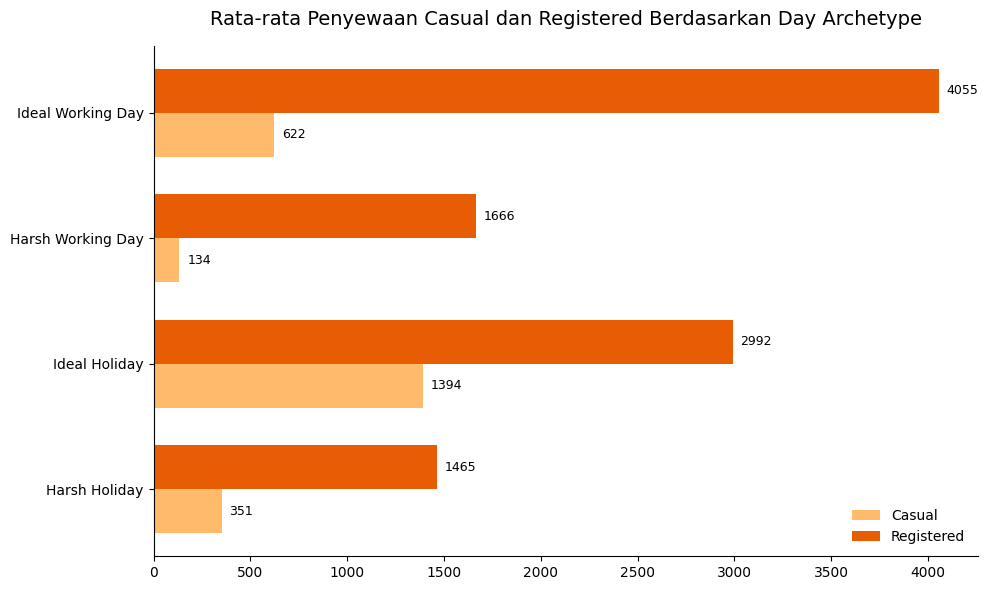

In [ ]:
archetype_order = ['Harsh Holiday', 'Ideal Holiday', 'Harsh Working Day', 'Ideal Working Day']

archetype_summary_df = days_df.groupby('Day_Archetype').agg(
    Rata_rata_Casual=('casual', 'mean'),
    Rata_rata_Registered=('registered', 'mean')
).round(1).reindex(archetype_order)

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(archetype_summary_df))
height = 0.35

bars_c = ax.barh(y - height/2, archetype_summary_df['Rata_rata_Casual'], height, label='Casual', color='#FFBA6B')
bars_r = ax.barh(y + height/2, archetype_summary_df['Rata_rata_Registered'], height, label='Registered', color='#E85D04')

for bars in [bars_c, bars_r]:
    for bar in bars:
        lebar = bar.get_width()
        ax.text(lebar + 40, bar.get_y() + bar.get_height()/2, f'{lebar:.0f}', va='center', fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(archetype_summary_df.index)
ax.set_title('Rata-rata Penyewaan Casual dan Registered Berdasarkan Day Archetype', fontsize=14, pad=15)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Teknik analisis yang digunakan adalah Clustering dengan metode Manual Grouping. Teknik ini dipilih karena dataset ini tidak memiliki data transaksi per pelanggan individual (sehingga RFM analysis tidak dapat dilakukan), maupun data koordinat atau lokasi geografis (yang dibutuhkan untuk Geospatial Analysis). Manual Grouping dipilih karena dapat memberikan segmentasi yang bisa digunakan untuk operasional/marketing, dan memperkuat visualisasi lain yang telah dibangun pada analisis sebelumnya (sensitivitas casual vs registered terhadap cuaca).

**Insight:** (Opsional)
- Berdasarkan hasil di atas, Ideal Working Day memiliki rata-rata penyewaan tertinggi. Hal ini bisa dilihat dari kriteria ideal working day sendiri, yaitu memiliki kewajiban untuk keluar rumah karena meurpakan hari kerja, dan kondisi cuaca yang bagus (tidak hujan ataupun bersalju). - Sebaliknya, harsh working day memiliki rata-rata penyewaan terendah, dengan rata-rata registered users lebih tinggi dibanding dengan rata-rata casual users.
- Terdapat perbedaan pada pola puncak antara casual users dan registered users yang disebabkan oleh motivasi bersepeda. Casual users memiliki rata-rata penyewaan tertinggi pada Ideal Holiday (hari libur dengan cuaca cerah), karena mereka tidak terikat oleh langganan atau kewajiban rutin (untuk menggunakan sepeda) sehingga penggunaan sepeda oleh casual users lebih bersifat impulsif dan situasional. Hal ini berarti casual users sangat bergantung pada momen (waktu senggang dan cuaca yang mendukung), sehingga wajar jika puncak berada pada hari libur. Sebaliknya, regiestered users memiliki rata-rata penyewaan tertinggi pada ideal working day, karena mereka merupakan pelanggan tetap sehingga sepeda adalah transportasi tetap untuk kebutuhan commuting. Akibatnya, pola pemakaian sepeda jauh lebih terjadwal dan konsisten mengikuti hari kerja, bukan mengikuti waktu senggang seperti pada casual users. Perbedaan ini menegaskan bahwa strategi bisnis kedua segmen perlu dibedakan, misalnya, promosi untuk casual users ccok dilakukan saat cuaca bagus di hari libur, sementara registered users lebih cocok dipertahankan lewat trustable service yang ditawarkan perusahaan pada jam-jam commuting di hari kerja.
- Untuk casual users, rata-rata penyewaan terendah terjadi saat harsh working day. Hal ini bisa disebabkan asumsi casual users pada dasarnya bersepeda karena pilihan, bukan keharusan, sehingga saat hari kerja bertepatan dengan cuaca buruk, bersepda hanya sebuah opsi yang dapat digantikan dengan transport lain yang lebih menguntungkan bagi mereka. Sementara untuk harh holiday (hari libur cuaca buruk), sebagian casual users yang mungkin memiliki rencana untuk berpergian masih mungkin nekat keluar karena tidak terikat jadwal kerja.
- Di sisi lain, untuk registered users, rata-rata penyewaan terendah di harsh leisure day, bukan harsh working day. Hal ini mengonfirmasi bahwa registered users memiliki kebutuhan yang bersifat wajib (menggunakan sepeda untuk ke tempat kerja karena telah berlangganan), sehingga cuaca buruk pada hari kerja tidak menjadi penghalang bagi mereka untuk tetap menyewa sepeda, berbeda dengan cuaca buruk pada hari libur yang tidak bersifat wajib untuk keluar rumah.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kombinasi hari dan jam dengan rata-rata penyewaan tertinggi adalah Selasa pukul 17.00 (544 penyewaan). Secara umum, jam 17.00 menjadi jam tersibuk di seluruh 5 hari kerja (Senin-Jumat), mencerminkan pola commuting (jam pulang kantor). Sebaliknya, pada akhir pekan (Sabtu-Minggu), puncak penyewaan bergeser ke pukul 13.00 dengan pola yang lebih landai, mengindikasikan aktivitas rekreasi di siang hari. Jam paling sepi konsisten terjadi pada dini hari (pukul 3-5). Walaupun Jumat adalah hari dengan rata-rata total harian tertinggi (4.690), jam puncaknya sendiri (Jumat 17.00) tidak sebesar Selasa maupun Kamis. Hal ini menunjukkan keunggulan Jumat berasal dari penyewaan yang merata sepanjang hari, bukan dari satu lonjakan ekstrem saja.
- **Conclusion pertanyaan 2:** Kondisi cuaca memengaruhi penyewaan secara signifikan. Hal ini bisa dilihat dari rata-rata penyewaan tertinggi terjadi saat cuaca Clear/cerah (204,9), dan terus menurun seiring cuaca memburuk hingga terendah saat Heavy Rain/Snow (74,3). Casual users jauh lebih sensitif terhadap cuaca buruk dibanding registered users. Regsitered users secara konsisten mendominasi jumlah penyewaan di semua kondisi cuaca.
- **Conclusion pertanyaan 3:** Proporsi pengguna casual menunjukkan pola musiman yang berulang secara konsisten di 2011 maupun 2012, yaitu naik pada pertengahan tahun (April-Agustus) dan turun tajam di awal-akhir tahun (Januari, November-Desember). Secara volume, penyewaan tahun 2012 konsisten lebih tinggi dibanding 2011 pada bulan yang sama, menandakan pertumbuhan bisnis yang solid.
- **Conclusion pertanyaan 4:** Ketiga variabel lingkungan berpengaruh terhadap penyewaan, namun dengan kekuatan yang berbeda. Temperatur adalah faktor paling dominan, dengan rata-rata penyewaan naik hampir 3x lipat dari kategori suhu Rendah (97,7) ke Sangat Tinggi (297,6). Kelembapan berpengaruh negatif signifikan, menurun dari 265,5 (kelembapan Rendah) ke 109,4 (Sangat Tinggi). Kecepatan angin memberi pengaruh paling lemah di antara ketiganya, bahkan menunjukkan titik jenuh. Hal ini dapat dilihat dari penurunan angka penyewaan saat angin sangat kencang dibanding kategori Tinggi. Dengan visualisasi di atas, dapat dikonfirmasi bahwa casual users jauh lebih reaktif terhadap perubahan ketiga variabel lingkungan dibanding registered users.

**Rekomendasi Action Item:**
- Ketersediaan sepeda pada weekdays khususnya pada jam masuk sekolah atau berangkat kerja di jam 7-8 dan jam 16-18 perlu ditingkatkan agar bisa melayani potensi pelanggan baru yang membutuhkan penyewaan sepeda pada jam tersebut. Hal ini didukung dengan visualisasi data bahwa pada kedua rentang jam tersebut, penyewaan sepeda lebih ramai dibanding jam lainnya. Hal ini akan memberikan kesempatan bagi penyedia layanan penyewaan sepeda untuk mengekspansi bisnis mereka.
- Diskon atau promo tertentu dapat diberikan khusus untuk kombinasi hari dan jam yang pada waktu itu memiliki cuaca dan kondisi lingkungan yang buruk atau ekstrem (yaitu saat ketika hujan/salju berat, temparatur rendah, humiditas tinggi, dan windspeed rendah) marena pada jam tersebut penyewa sepeda lebih sepi. Promosi ini diharapkan dapat membantu menahan penurunan drastis penyewa tersebut pada kondisi tersebut.
- Pada musim Summer atau Fall, yaitu musim dengan jumlah penyewaan yang sangat tinggi, kampanye marketing dapat ditingkatkan untuk menarik pengguna casual baru. Hal ini karena pada kedua musim itu, jumlah penyewa casual lumayan tinggi dibanding saat spring ataupun winter dan asumsi bahwa penyewa casual merupakan calon penyewa registered. Harga penyewaan sepeda pada musim ini juga dapat ditinggikan melihat banyak penyewa, baik casual dan registered gemar bersepeda pada musim tersebut.
- Momen cuaca ekstrem menjadi titik yang tepat bagi bisnis penyewaan sepeda untuk mengonversi penyewa casual menjadi member karena saat cuaca memburuk, pengguna casual turun drastis, sedangkan registered masih relatif stabil. Hal ini dapat dilakukan dengan cara mengirimkan notifikasi dan tawaran diskon pendaftaran emmbersih dengan besaran yang meningkat sesuai tingkat keparahan cuaca, atau progrem free trial membership singkat bagi casual rider yang aktif menyewa tepat sebelum musim spring atau winner dimulai, agar bisa merasakan langsung menfaat sebagai member sebelum berlangganan penuh. Pemilik penyewaan sepeda harus menjanjikan dengan mengonversi menjadi penyewa registered, mereka tidak perlu lagi repot mencari kendaraan saat cuaca buruk karena sudah terdaftar.
- Bisnis penyewaan sepeda dapat menggunakan data temperatur, humiditas, dan windspeed sebagai indikator prediktif harian untuk perencanaan distribusi sepeda dan staf operasional, sehingga perusahaan dapat mengantisipasi lonjakan maupun penurunan permintaan sebelum terjadi.

In [ ]:
hours_df.to_csv("bike_sharing_hourly_clean.csv", index=False)